In [4]:
import matplotlib.pyplot as plt
import numpy as np
import PIL 
import tensorflow as tf
from tensorflow.keras import layers
import os 
import pathlib
import urllib.request
import tarfile

In [7]:
# 데이터 다운로드 함수
def download_and_extract() :
    # 데이터 URL
    dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

    # 다운로드할 디렉토리 생성
    download_dir = os.path.join(os.getcwd(), "flower_dataset")
    os.makedirs(download_dir, exist_ok=True)

    # 파일 다운로드
    tgz_path = os.path.join(download_dir, "flower_photos.tgz")

    if not os.path.exists(tgz_path) :
        print("데이터셋 다운로드 중...")
        urllib.request.urlretrieve(dataset_url, tgz_path) # 지정된 URL에서 파일을 직접 다운로드하여 로컬에 저장
        print("다운로드 완료!")
    
    # 압축 해제
    if not os.path.exists(os.path.join(download_dir, "flower_photos")) :
        print("압축 해제 중...")
        with tarfile.open(tgz_path) as tar :
            tar.extractall(path=download_dir)
        print("압축 해제 완료!")
    return os.path.join(download_dir, "flower_photos")

In [8]:
# 데이터 다운로드 및 경로 설정
data_dir = download_and_extract() # 함수호출
data_dir = pathlib.Path(data_dir) # 현재작업 경로/flower_dataset/flower_photos을 data_dir 변수에 저장


데이터셋 다운로드 중...
다운로드 완료!
압축 해제 중...
압축 해제 완료!


In [9]:
# 클래스 및 이미지 개수 확인
# data_dir.glob('*/') : data_dir(pathlib.Path 객체) 아래의 모든 하위 디렉토리를 탐색
# item.is_dir() : 탐색된 각 항목이 디렉토리인지 확인하는 조건
classes = sorted([item.name for item in data_dir.glob('*/') if item.is_dir()]) # 리스트 컴프리헨션을 사용
image_count = len(list(data_dir.glob('*/*.jpg')))
print(f"발견된 클래스 : {classes}")
print(f"총 이미지 개수 : {image_count}")

발견된 클래스 : ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
총 이미지 개수 : 3670


In [10]:
# 각 클래스별 이미지 개수 확인
for class_name in classes :
    class_images = len(list(data_dir.glob(f'{class_name}/*')))
    print(f"{class_name} : {class_images}개 이미지")

daisy : 633개 이미지
dandelion : 898개 이미지
roses : 641개 이미지
sunflowers : 699개 이미지
tulips : 799개 이미지


In [11]:
# 이미지 크기 및 배치 크기 설정
img_height = 180
img_width = 180
batch_size = 32


In [12]:
# 훈련 데이터셋 생성 (cf. image_dataset_from_directory : 자동으로 폴더기준 라벨을 부여하는 함수)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    str(data_dir),
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)  

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [13]:
# 검증 데이터셋 생성
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    str(data_dir),
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [14]:
# 클래스 이름 확인
class_names = train_ds.class_names # class_names : 하위 폴더 이름들을 클래스 이름으로 인식
print(f"클래스 이름 : {class_names}")
num_classes = len(class_names)

클래스 이름 : ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [15]:
# 데이터셋 성능 최적화
AUTOTUNE = tf.data.AUTOTUNE # 시스템 자원 (CPU, GPU) 자동 튜닝
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE) # 배치를 처리하는 동안 다음 배치를 미리 준비

In [16]:
# 데이터 증강 레이어 정의
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

In [17]:
# CNN 모델 구성
model = tf.keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])


d:\python_sim\venv\lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
# 모델 컴파일
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])


In [20]:
# Early Stopping 콜백 설정 (조기 종료)
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
]



In [21]:
# 모델 학습
epochs = 15
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 285ms/step - accuracy: 0.3971 - loss: 1.3751 - val_accuracy: 0.5708 - val_loss: 1.0436
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 257ms/step - accuracy: 0.5691 - loss: 1.0600 - val_accuracy: 0.6349 - val_loss: 0.9478
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 245ms/step - accuracy: 0.6196 - loss: 0.9601 - val_accuracy: 0.6376 - val_loss: 0.9295
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 251ms/step - accuracy: 0.6557 - loss: 0.8921 - val_accuracy: 0.6485 - val_loss: 0.8911
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 249ms/step - accuracy: 0.6672 - loss: 0.8605 - val_accuracy: 0.6880 - val_loss: 0.8467
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 238ms/step - accuracy: 0.6826 - loss: 0.8096 - val_accuracy: 0.6649 - val_loss: 0.8584
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 245ms/step - accuracy: 0.6843 - loss: 0.8160 - val_accuracy: 0.6649 - val_loss: 0.8601
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 256ms/step - accuracy: 0.7023 - loss: 0.7721 - val_accu

In [22]:
# 모델 구조 출력
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,967,857 (45.65 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,978,572 (30.44 MB)

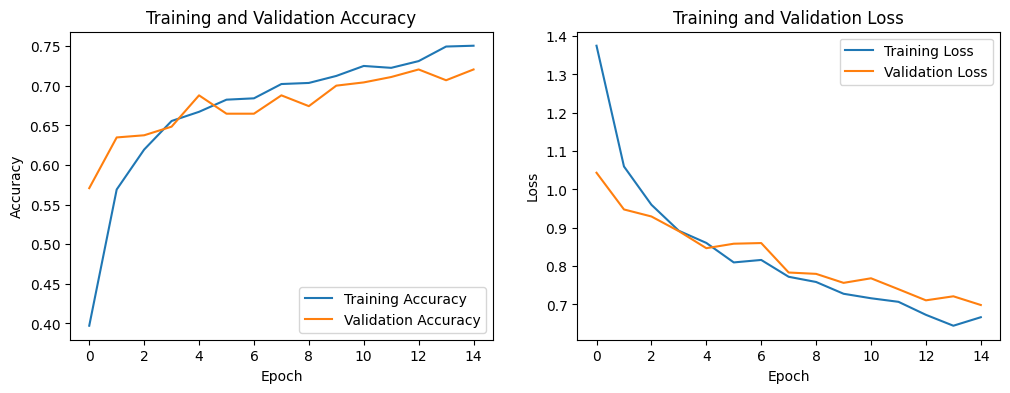

In [23]:
# 학습 결과 시각화
acc = history.history['accuracy'] # 뒤의 history는 학습 과정을 담고 있는 딕셔너리
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()



In [24]:
# 모델 저장
model.save('./model/flower_classification_model.h5')
print('모델이 저장되었습니다.')

모델이 저장되었습니다.


In [25]:
# 저장된 모델 불러오기
from tensorflow.keras.models import load_model

In [26]:
model_path = './model/flower_classification_model.h5'
loaded_model = load_model(model_path)
print('저장된 모델이 성공적으로 로드되었습니다.')

저장된 모델이 성공적으로 로드되었습니다.


In [27]:
# 저장된 모델을 활용한 이미지 예측 함수
def predict_flower_with_loaded_model(img_path, model, class_names) :
    """
    이미지 경로와 모델을 입력받아 예측 결과를 출력하고 이미지를 시각화하는 ㅎ마수

    Parameters : 
        img_path : 이미지 파일 경로
        model (tf.keras.Model) : 저장된 모델,
        class_names (list) : 클래스 이름 리스트
    """
    # 이미지 로드 및 전처리
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(img_height, img_width)) # PIL 이미지 객체
    img_array = tf.keras.preprocessing.image.img_to_array(img) # 이미지를 배열로 변환
    img_array = tf.expand_dims(img_array, 0) # 배열 차원 증가 (batch 차원 추가)

    # 예측 수행
    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    # 예측 결과 출력
    print(
     "이 이미지는 '{}' ({:.2f}%) 확률로 예측됩니다."
     .format(class_names[np.argmax(score)], 100 * np.max(score))
    )

    # 이미지 시각화
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    


In [28]:
# 테스트 이미지 경로
test_image_path = './flower_dataset/flower_photos/roses/12240303_80d87f77a3_n.jpg'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step
이 이미지는 'roses' (31.67%) 확률로 예측됩니다.


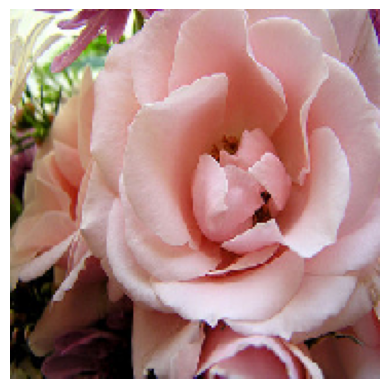

In [29]:
# 예측 실행
predict_flower_with_loaded_model(test_image_path, loaded_model, class_names)